In [99]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from pathlib import Path

In [100]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [101]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [102]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [103]:
llm = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0.2)

In [104]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Generate a structured blog plan containing 5–7 sections for the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [105]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [106]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()
    return {"sections": [section_md]}

In [107]:
def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    #save to file
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [108]:
graph= StateGraph(State)
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

graph.add_edge(START, "orchestrator")
graph.add_conditional_edges("orchestrator", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

workflow = graph.compile()

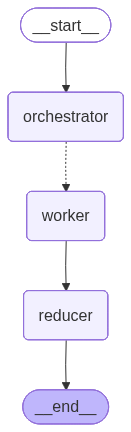

In [109]:
workflow

In [110]:
out = workflow.invoke({"topic": "Write a blog on Neural Network", "sections": []})

In [112]:
print(out["final"])

# Understanding Neural Networks: From Basics to Advanced Concepts

## Introduction to Neural Networks

Neural networks are computational models inspired by the structure and function of the human brain. At their core, they consist of layers of interconnected nodes (or *neurons*) that process input data and propagate signals through weighted connections. Each neuron applies a simple mathematical operation—typically a weighted sum followed by a non‑linear activation function—to its inputs, producing an output that feeds into the next layer. By stacking many such layers, a neural network can learn complex, hierarchical representations of data.

### A Brief History

The idea of artificial neurons dates back to the 1940s with Warren McCulloch and Walter Pitts, who formalized a binary neuron model. In the 1950s and 1960s, Frank Rosenblatt introduced the perceptron, a single‑layer network capable of learning linear decision boundaries. However, the field stalled in the 1970s and 1980s due to 